In [2]:
 #pip install git+https://github.com/MaximeJumelle/ALEPython.git@dev#egg=alepython

In [1]:
#pip install shap

#  Interpreting Machine Learning Models for Electric Vehicle Analysis

In this notebook, we explore interpretability methods applied to a regression task on electric vehicle specifications. Using a dataset containing technical and performance attributes of electric cars, I aim to understand how different features—such as acceleration, top speed, and battery capacity—influence the predicted price of an electric vehicle. I employ both global and local interpretability techniques seeing on the course. Specifically, I use:  SHAP values, Partial Dependence Plots (PDP), Individual Conditional Expectation (ICE) and Accumulated Local Effects (ALE), to shed light on the decision-making process of machine learning models such as Linear Regression and Random Forest. 

In [8]:
# Import required libraries for data manipulation, modeling, evaluation, and explainability

import numpy as np
import pandas as pd
import os
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error,mean_squared_error
from sklearn.metrics import r2_score
import scipy as sp
import matplotlib.pyplot as plt
from sklearn.ensemble import RandomForestRegressor

from sklearn.preprocessing import StandardScaler, OneHotEncoder, OrdinalEncoder
from sklearn.compose import ColumnTransformer
from sklearn.ensemble import RandomForestRegressor
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder

from alibi.explainers import PartialDependence, plot_pd
from sklearn.inspection import PartialDependenceDisplay
from sklearn.ensemble import HistGradientBoostingRegressor

In [ ]:
# Load the cleaned electric car dataset from a CSV file available on https://www.kaggle.com/datasets/geoffnel/evs-one-electric-vehicle-dataset
df = pd.read_csv("ElectricCarData_Clean.csv")

# Overview of the Electric Car Dataset

The dataset contains various attributes of electric vehicles, providing insights into their performance, efficiency, and pricing. Below are the key features included:

- **Brand**: The manufacturer of the electric vehicle (e.g., Tesla, Volkswagen, BMW).
- **Model**: The specific model name of the car.
- **AccelSec**: Acceleration time from 0 to 100 km/h in seconds.
- **TopSpeed_KmH**: Maximum speed of the vehicle in km/h.
- **Range_Km**: Estimated driving range of the vehicle in kilometers.
- **Efficiency_WhKm**: Energy consumption in watt-hours per kilometer.
- **FastCharge_KmH**: Estimated fast-charging rate in km per hour.
- **RapidCharge**: Indicates whether the car supports rapid charging (Yes/No).
- **PowerTrain**: Type of drivetrain (e.g., AWD - All Wheel Drive, RWD - Rear Wheel Drive).
- **PlugType**: The charging port type used (e.g., Type 2 CCS).
- **BodyStyle**: The design category of the vehicle (e.g., Sedan, SUV, Hatchback).
- **Segment**: The market segment classification (e.g., B, C, D).
- **Seats**: The number of seats in the vehicle.
- **PriceEuro**: The price of the car in euros.



In [4]:
# Display the first few rows of the dataset to understand its structure
df.head()

,Brand,Model,AccelSec,TopSpeed_KmH,Range_Km,Efficiency_WhKm,FastCharge_KmH,RapidCharge,PowerTrain,PlugType,BodyStyle,Segment,Seats,PriceEuro
0,Tesla,Model 3 Long Range Dual Motor,4.6,233,450,161,940,Yes,AWD,Type 2 CCS,Sedan,D,5,55480
1,Volkswagen,ID.3 Pure,10.0,160,270,167,250,Yes,RWD,Type 2 CCS,Hatchback,C,5,30000
2,Polestar,2,4.7,210,400,181,620,Yes,AWD,Type 2 CCS,Liftback,D,5,56440
3,BMW,iX3,6.8,180,360,206,560,Yes,RWD,Type 2 CCS,SUV,D,5,68040
4,Honda,e,9.5,145,170,168,190,Yes,RWD,Type 2 CCS,Hatchback,B,4,32997


In [4]:
df.shape

(103, 14)

In [5]:
# Display dataset info to understand data types and missing values
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 103 entries, 0 to 102
Data columns (total 14 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   Brand            103 non-null    object 
 1   Model            103 non-null    object 
 2   AccelSec         103 non-null    float64
 3   TopSpeed_KmH     103 non-null    int64  
 4   Range_Km         103 non-null    int64  
 5   Efficiency_WhKm  103 non-null    int64  
 6   FastCharge_KmH   103 non-null    object 
 7   RapidCharge      103 non-null    object 
 8   PowerTrain       103 non-null    object 
 9   PlugType         103 non-null    object 
 10  BodyStyle        103 non-null    object 
 11  Segment          103 non-null    object 
 12  Seats            103 non-null    int64  
 13  PriceEuro        103 non-null    int64  
dtypes: float64(1), int64(5), object(8)
memory usage: 11.4+ KB


In [7]:
# Encode categorical columns into numerical values using LabelEncoder
le = LabelEncoder()

df2=df.copy()
df2['Brand'] = le.fit_transform(df2['Brand'])
df2['Model'] = le.fit_transform(df2['Model'])
df2['RapidCharge'] = le.fit_transform(df2['RapidCharge'])
df2['PowerTrain'] = le.fit_transform(df2['PowerTrain'])
df2['PlugType'] = le.fit_transform(df2['PlugType'])
df2['BodyStyle'] = le.fit_transform(df2['BodyStyle'])
df2['Segment'] = le.fit_transform(df2['Segment'])

We drop the rows that don't have information regarding Fast Charge

In [7]:
df.loc[df['FastCharge_KmH']=='-']

,Brand,Model,AccelSec,TopSpeed_KmH,Range_Km,Efficiency_WhKm,FastCharge_KmH,RapidCharge,PowerTrain,PlugType,BodyStyle,Segment,Seats,PriceEuro
57,Renault,Twingo ZE,12.6,135,130,164,-,No,RWD,Type 2,Hatchback,A,4,24790
68,Renault,Kangoo Maxi ZE 33,22.4,130,160,194,-,No,FWD,Type 2,SPV,N,5,38000
77,Smart,EQ forfour,12.7,130,95,176,-,No,RWD,Type 2,Hatchback,A,4,22030
82,Smart,EQ fortwo coupe,11.6,130,100,167,-,No,RWD,Type 2,Hatchback,A,2,21387
91,Smart,EQ fortwo cabrio,11.9,130,95,176,-,No,RWD,Type 2,Cabrio,A,2,24565


In [6]:
df2=df2.drop(index=[57,68,77,82,91],axis=1)

In [7]:
df2['FastCharge_KmH'] = df2['FastCharge_KmH'].astype(int)

In [8]:
df2.info()

<class 'pandas.core.frame.DataFrame'>
Index: 98 entries, 0 to 102
Data columns (total 14 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   Brand            98 non-null     int32  
 1   Model            98 non-null     int32  
 2   AccelSec         98 non-null     float64
 3   TopSpeed_KmH     98 non-null     int64  
 4   Range_Km         98 non-null     int64  
 5   Efficiency_WhKm  98 non-null     int64  
 6   FastCharge_KmH   98 non-null     int32  
 7   RapidCharge      98 non-null     int32  
 8   PowerTrain       98 non-null     int32  
 9   PlugType         98 non-null     int32  
 10  BodyStyle        98 non-null     int32  
 11  Segment          98 non-null     int32  
 12  Seats            98 non-null     int64  
 13  PriceEuro        98 non-null     int64  
dtypes: float64(1), int32(8), int64(5)
memory usage: 8.4 KB


### We aim to predict the price in Euros of the electric vehicle. As a baseline, we start with a linear regression model and analyze the model results.


# Linear Regression

In [9]:
X=df2.drop('PriceEuro',axis=1)
y=df2['PriceEuro']
X_train,X_test,y_train,y_test=train_test_split(X,y,test_size=0.5,random_state=42)
lr=LinearRegression()
lr.fit(X_train,y_train)

LinearRegression()

In [10]:
test_predictions=lr.predict(X_test)
print('MAE:',mean_absolute_error(y_test,test_predictions))
print('MSE:',mean_squared_error(y_test,test_predictions))
print('RMSE:',np.sqrt(mean_squared_error(y_test,test_predictions)))

MAE: 11473.953030932571
MSE: 285344396.0894858
RMSE: 16892.140068371617


In [11]:
print(f'Train Score:{lr.score(X_train,y_train)}')
print(f'Test Score:{lr.score(X_test,y_test)}')

Train Score:0.8843197898476522
Test Score:0.7127601125770593


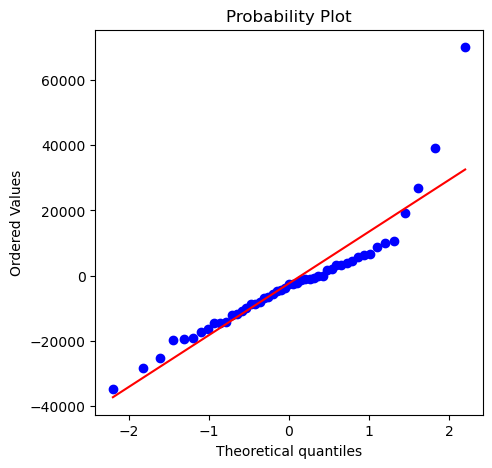

In [12]:
test_res=y_test-test_predictions

fig,ax=plt.subplots(figsize=(5,5))
_=sp.stats.probplot(test_res,plot=ax)

# Random Forest Regression

In [13]:
rfg=RandomForestRegressor(n_jobs=-1,random_state=42)
rfg.fit(X_train,y_train)
test_predictions=rfg.predict(X_test)
print('MAE:',mean_absolute_error(y_test,test_predictions))
print('MSE:',mean_squared_error(y_test,test_predictions))
print('RMSE:',np.sqrt(mean_squared_error(y_test,test_predictions)))

MAE: 7724.725510204082
MSE: 152340726.04892448
RMSE: 12342.638536752362


In [14]:
X_trainPDP = X_train.copy()

In [17]:
print(f'train score:{rfg.score(X_train,y_train)}')
print(f'test score:{rfg.score(X_test,y_test)}')

train score:0.9425262617249742
test score:0.846647301997481


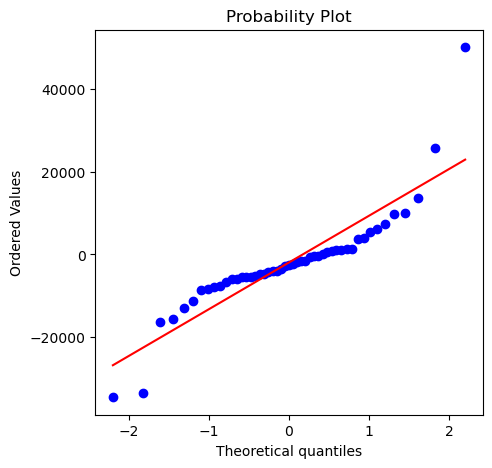

In [15]:
test_res=y_test-test_predictions

fig,ax=plt.subplots(figsize=(5,5))
_=sp.stats.probplot(test_res,plot=ax)

# Comparison of Linear Regression and Random Forest Regression Models

The performance of the **Linear Regression** and **Random Forest Regression** models was evaluated using key regression metrics: **Mean Absolute Error (MAE)**, **Mean Squared Error (MSE)**, and **Root Mean Squared Error (RMSE)**

- **Linear Regression:**
  - MAE: **11,479.95**
  - MSE: **285,843,56.07**
  - RMSE: **16,892.14**
  - Train Score (R²): **0.884**
  - Test Score (R²): **0.718**

- **Random Forest Regression:**
  - MAE: **7,724.75**
  - MSE: **152,342,76.69**
  - RMSE: **12,324.63**
  - Train Score (R²): **0.9425**
  - Test Score (R²): **0.8466**

### Observations:
1. **Error Reduction:** The Random Forest model significantly reduces MAE, MSE, and RMSE compared to the Linear Regression model, indicating better predictive performance.
3. **Better Predictive Power:** The lower error values suggest that the Random Forest model captures complex relationships in the data better than the simple Linear Regression model.

In conclusion, the **Random Forest model outperforms the Linear Regression model** in terms of error metrics, making it a preferable choice for predicting electric vehicle prices.


**Nevertheless, the main drawback of the Random Forest model is its lack of interpretability. To address this, we will use some interpretation methods discussed in class.**

# Interpretability

# Global Model-Agnostic Methods

## Partial Dependence Plots (PDP)

In [ ]:
from pdpbox import pdp, info_plots

In [24]:
feature_names = ['Brand', 'Model', 'AccelSec', 'TopSpeed_KmH', 'Range_Km',
       'Efficiency_WhKm', 'FastCharge_KmH', 'RapidCharge', 'PowerTrain',
       'PlugType', 'BodyStyle', 'Segment', 'Seats']

In [ ]:
#https://www.kaggle.com/code/earije/regression-of-electric-car-data

obtain pred_func from the provided model.


  0%|          | 0/10 [00:00<?, ?it/s]

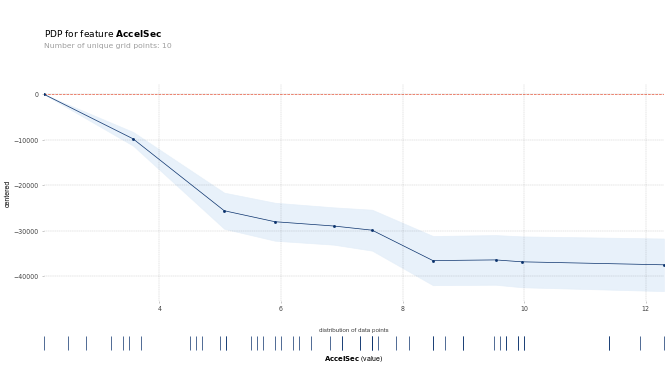

obtain pred_func from the provided model.


  0%|          | 0/9 [00:00<?, ?it/s]

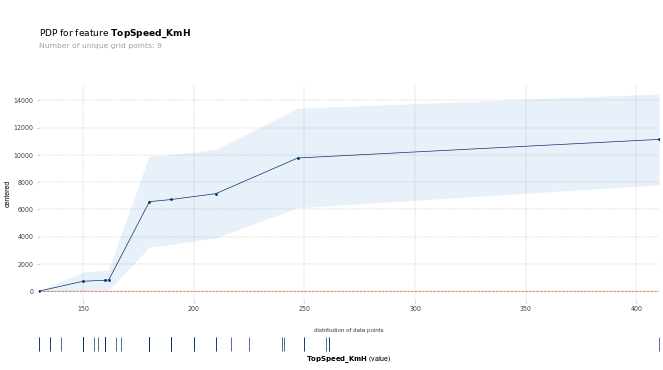

obtain pred_func from the provided model.


  0%|          | 0/10 [00:00<?, ?it/s]

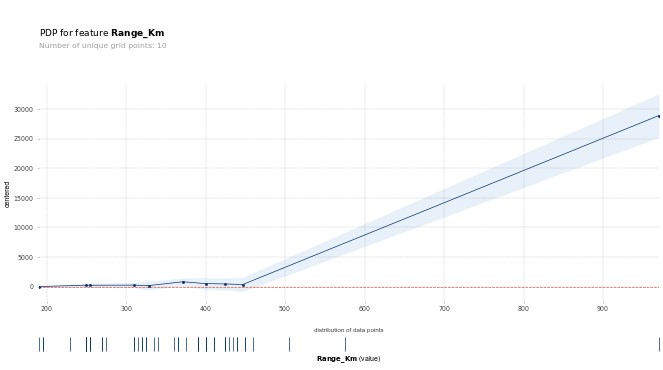

obtain pred_func from the provided model.


  0%|          | 0/10 [00:00<?, ?it/s]

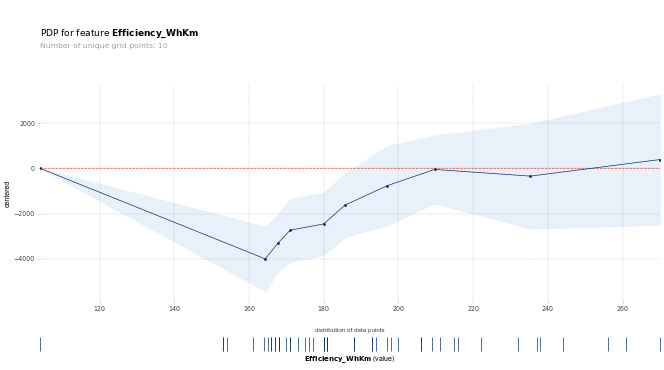

obtain pred_func from the provided model.


  0%|          | 0/10 [00:00<?, ?it/s]

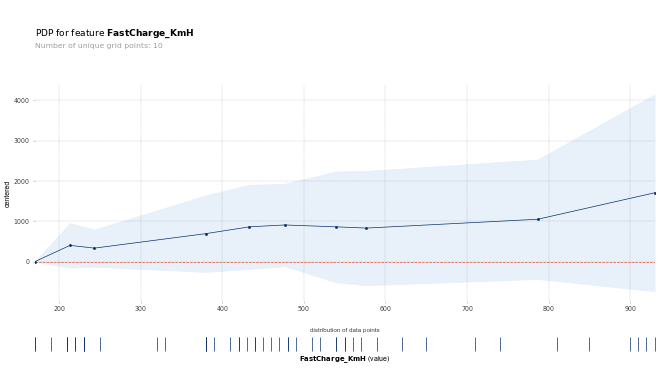

In [55]:
import matplotlib.pyplot as plt

# List of features to analyze
features = ['AccelSec','TopSpeed_KmH', 'Range_Km', 'Efficiency_WhKm', 'FastCharge_KmH']

# Generate and plot PDP for each feature
for feature in features:
    # Compute PDP for the current feature
    pdp_isolate = pdp.PDPIsolate(
        model=rfg,
        df=X_trainPDP,
        model_features=feature_names,
        feature=feature,
        feature_name=feature,
        n_classes=0,
    )
    
    # Plot settings
    pdp_isolate.plot(
        center=True,
        engine="matplotlib",
        dpi=50,
        plot_pts_dist=True,
    )
    plt.show()  # Display the plot

### Partial Dependence Analysis of Electric Vehicle Features

The Partial Dependence Plots (PDPs) provide insights into how individual features influence the predicted price of electric vehicles in the dataset. Below is a summary of the key findings:

- **Acceleration Time (AccelSec)**: A strong negative correlation is observed between acceleration time and price, indicating that vehicles with faster acceleration (lower AccelSec values) tend to be more expensive.
- **Top Speed (TopSpeed_KmH)**: As expected, vehicles with higher top speeds generally command higher prices, with a significant increase in predicted price observed beyond approximately 200 km/h.
- **Range (Range_Km)**: A strong positive correlation exists between vehicle range and price. Beyond 400 km, the predicted price increases significantly, suggesting that long-range electric vehicles are valued at a premium.
- **Efficiency (Efficiency_WhKm)**: A non-linear relationship is observed, where lower energy consumption (higher efficiency) is associated with lower prices up to a certain threshold, beyond which the price trend stabilizes.
- **Fast Charging Speed (FastCharge_KmH)**: Vehicles with higher fast-charging speeds tend to have slightly higher predicted prices, though the effect is less pronounced compared to range or acceleration.

These insights suggest that premium electric vehicles could typically be characterized by faster acceleration, higher top speeds, extended range, and fast-charging capabilities. Understanding these relationships can help manufacturers and consumers evaluate the trade-offs between performance and cost when selecting an electric vehicle.

## Accumulated Local Effects (ALE)

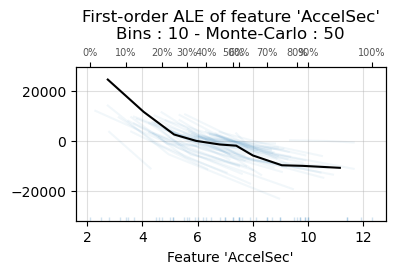

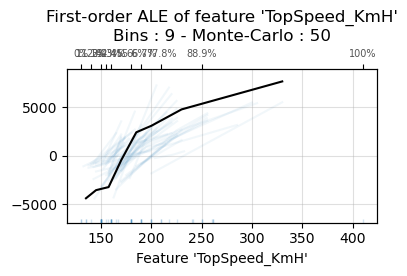

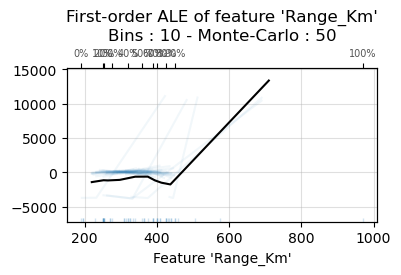

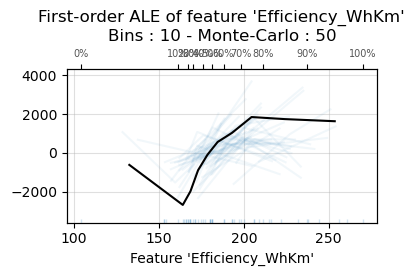

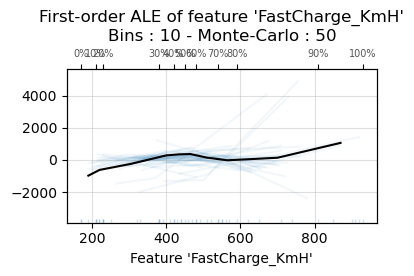

In [77]:
from alepython import ale_plot
# Plots ALE of feature 'cont' with Monte-Carlo replicas (default : 50).
plt.rc("figure", figsize=(4, 2))
for feature in features:
    ale_plot(rfg, X_train, feature, monte_carlo=True)


### ALE Analysis of Electric Vehicle Features

The **Accumulated Local Effects (ALE) plots** highlight key price influencers in EVs:

- **Acceleration (AccelSec)**: Strong **negative effect**—faster cars (lower AccelSec) are significantly more expensive, especially under **6s**.
- **Top Speed (TopSpeed_KmH)**: Prices **jump sharply around 150-200 km/h**, then increase steadily.
- **Range (Range_Km)**: Minimal impact below **400 km**, but **sharp price rise beyond**.
- **Efficiency (Efficiency_WhKm)**: **Non-linear effect**—optimal pricing occurs around **180-220 Wh/km**.
- **Fast Charging (FastCharge_KmH)**: **Weak influence** on price compared to other features.

ALE provides a **better-adjusted** view of price dependencies than traditional methods.


# Local Model-Agnostic Methods

# Individual Conditional Expectation (ICE)

Computing partial dependence plots and individual conditional expectation...
done in 1.067s


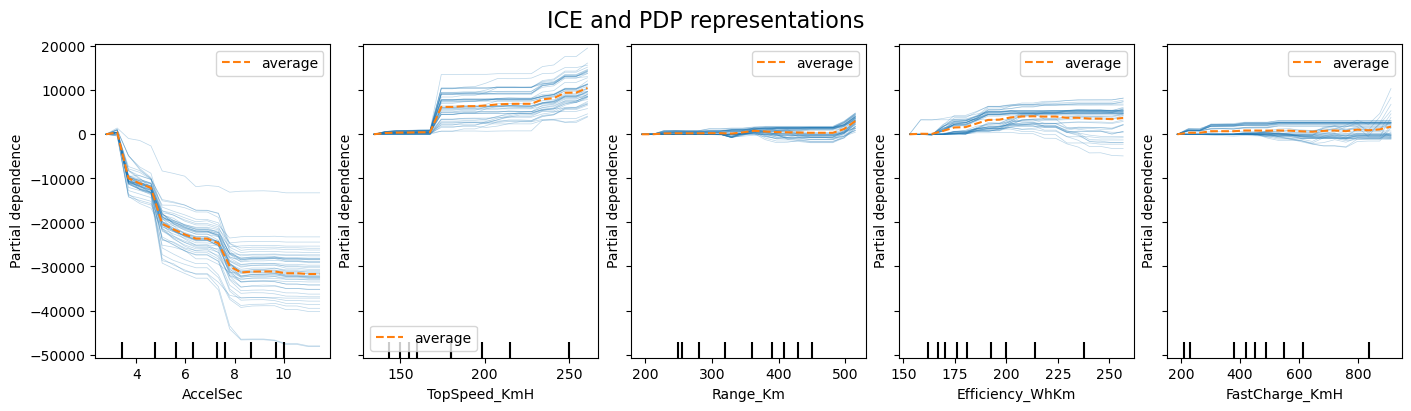

In [37]:
from time import time

common_params = {
    "subsample": 50,
    "n_jobs": 2,
    "grid_resolution": 20,
    "random_state": 0,
}
print("Computing partial dependence plots and individual conditional expectation...")
tic = time()
_, ax = plt.subplots(ncols=5, figsize=(14, 4), sharey=True, constrained_layout=True)
features = ['AccelSec','TopSpeed_KmH', 'Range_Km', 'Efficiency_WhKm', 'FastCharge_KmH']
features_info = {
    "features": ['AccelSec','TopSpeed_KmH','Range_Km','Efficiency_WhKm','FastCharge_KmH'],
    "kind": "both",
    "centered": True,
}

display = PartialDependenceDisplay.from_estimator(
    rfg,
    X_train,
    **features_info,
    ax=ax,
    **common_params,
)
print(f"done in {time() - tic:.3f}s")
_ = display.figure_.suptitle("ICE and PDP representations", fontsize=16)

### ICE Analysis of Electric Vehicle Features

The **Individual Conditional Expectation (ICE) plots** provide a granular view of how each vehicle’s price prediction responds to changes in specific features, highlighting individual variations rather than just the overall trend. Some comment on this:

- **Acceleration Time (AccelSec)**:
  - Most individual curves show a steep downward slope, indicating that as acceleration time increases (slower acceleration), the price prediction drops significantly.
  - The spread among individual data points suggests that while this trend is consistent across vehicles, some models exhibit a sharper price decline than others.

- **Top Speed (TopSpeed_KmH)**:
  - ICE curves reveal a step-like increase in predicted price around 200 km/h, suggesting a threshold effect where vehicles above this speed are valued higher.
  - While the general trend is upward, some individual lines show flat or minor increases, indicating that not all models benefit equally from higher top speeds.

- **Range (Range_Km)**:
  - ICE curves mostly exhibit **gradual upward trends**, showing that longer-range vehicles tend to have higher predicted prices.
  - However, the spread is relatively small, meaning the price effect of increasing range is more uniform across vehicles compared to acceleration or top speed.

- **Efficiency (Efficiency_WhKm)**:
  - Unlike other features, ICE curves for efficiency display diverse behaviors —some vehicles show price increases with improved efficiency, while others remain flat or even slightly decline.
  - This suggests that efficiency’s impact on price varies depending on other vehicle attributes, making it a less direct price determinant.

- **Fast Charging Speed (FastCharge_KmH)**:
  - Most ICE curves remain nearly flat, implying that fast-charging capability has a limited and less consistent effect on predicted price.
  - A few vehicles exhibit slight price increases at higher charging speeds, but the variation is minimal compared to other features.





# SHAP (SHapley Additive exPlanations)

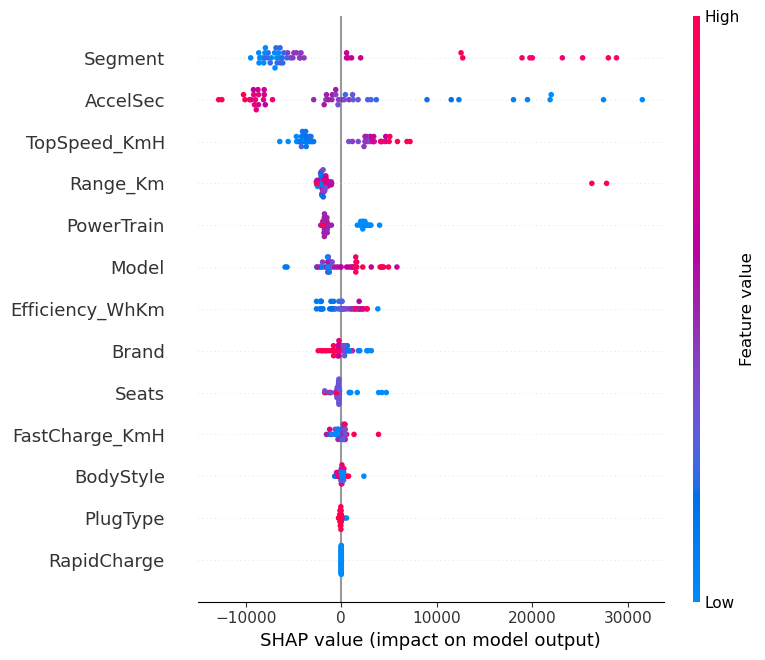

In [79]:
import shap

# Initialize the SHAP explainer for Random Forest
explainer = shap.TreeExplainer(rfg)

# Compute SHAP values for training data
shap_values = explainer.shap_values(X_train)

# Summarize Feature Importance
shap.summary_plot(shap_values, X_train)


# SHAP Summary Analysis: EV Price Prediction

This summary plot shows the global impact of features on the predicted price.

## Key Insights:
- **Segment and Acceleration (AccelSec) have the strongest influence**. Lower acceleration times increase prices.
- **Top Speed and Range show mixed effects**, with higher speeds generally increasing price.
- **PowerTrain and Efficiency impact pricing**, but efficiency tends to lower price.
- **Fast Charge Speed and Brand have moderate influence**.
- **Seats and Body Style play a minor role**.

In [85]:
# Extract the actual price for the first instance in y_train
actual_price = y_train.iloc[0]

# Print the actual price
print(f"Actual Price for Instance 0: €{actual_price}")


Actual Price for Instance 0: €61480


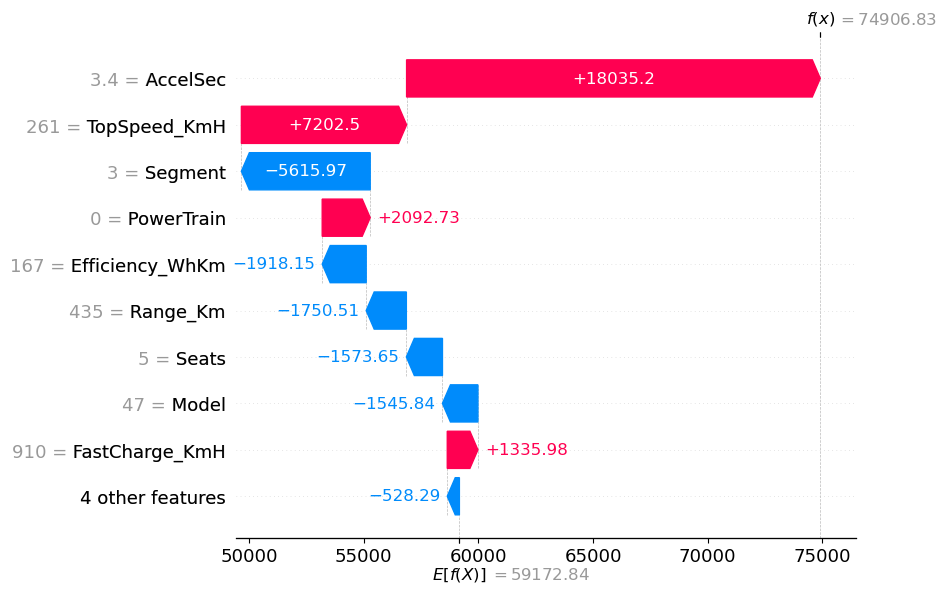

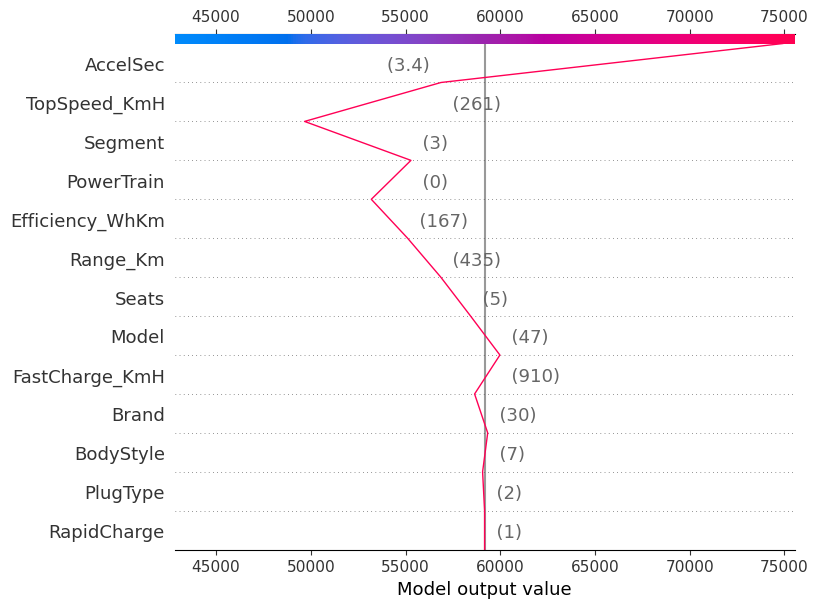

Brand               30.0
Model               47.0
AccelSec             3.4
TopSpeed_KmH       261.0
Range_Km           435.0
Efficiency_WhKm    167.0
FastCharge_KmH     910.0
RapidCharge          1.0
PowerTrain           0.0
PlugType             2.0
BodyStyle            7.0
Segment              3.0
Seats                5.0
Name: 24, dtype: float64


In [86]:
import shap
import matplotlib.pyplot as plt

# Initialize SHAP explainer for RandomForestRegressor
explainer = shap.TreeExplainer(rfg)

# Compute SHAP values for the training data
shap_values = explainer.shap_values(X_train)

# Select an instance (e.g., the first one) to analyze locally
instance_idx = 0  # Change this to any index for another sample
instance = X_train.iloc[instance_idx]

# Force Plot - Local Explanation for one prediction
shap.initjs()
shap.force_plot(explainer.expected_value, shap_values[instance_idx], instance)

# Waterfall Plot - Explains how each feature contributes to prediction
shap.plots.waterfall(shap.Explanation(values=shap_values[instance_idx], 
                                      base_values=explainer.expected_value, 
                                      data=instance))

# Decision Plot - Shows how each feature affects the model’s decision
shap.decision_plot(explainer.expected_value, shap_values[instance_idx], instance)
print(X_train.iloc[instance_idx])
plt.show()


For this specific electric vehicle, the model predicts a price of €74,906.83, starting from an average base price of €59,172.84. 

 # Waterfall Plot Analysis
The **waterfall plot** explains the contribution of each feature to a specific prediction:

- The base value (expected mean prediction) is **€59,172.84**.
- The final predicted price for this specific vehicle is **€74,906.83**.
- The most influential factors for this prediction:
  - **Acceleration (AccelSec = 3.4s)** increases the price by **€18,035.2**.
  - **Top Speed (TopSpeed_KmH = 261 km/h)** contributes **€7,202.5** to the price.
  - **PowerTrain (0)** adds **€2,092.73**.
  - **Segment (3)** decreases the price by **€-5,615.97**.
  - **Range (Range_Km = 435 km)** slightly lowers the price by **€-1,750.51**.
  - **Efficiency (Efficiency_WhKm = 167 Wh/km)** has a negative impact of **€-1,918.15**.
  - Other minor features contribute smaller adjustments.

Features like **high acceleration, top speed, and powertrain type** drive the price up, while **range, efficiency, and segment classification** may reduce it.

---

##  **Decision Plot Analysis**
The decision plot provides a visual representation of how the model arrived at the final price:

- The **starting value** is the expected average price (~€59,172).
- As the model moves through the decision path:
  - **Acceleration and top speed push the price higher**.
  - **Range and efficiency slightly decrease the price**.
  - The final **predicted price aligns with the highest feature contributions**.


##  **Final Comments**

This notebook demonstrates the use of interpretable machine learning techniques to analyze electric vehicle data. By leveraging linear regression alongside advanced explainability tools such as SHAP and ALE, it not only delivers accurate predictions but also highlights the key factors driving those outcomes—like acceleration, battery capacity, and top speed. The structured approach makes the results accessible and actionable, especially for understanding the "why" behind model decisions. I’ve also applied the methods during my internship at Orange.